Notebook to compare datasets from scaringi 2023. Made in CV_pop_create.py
- CV population in dat_maxDistance_1000_final.txt (CV_pop)
- CV GW information in dat_maxDistance_1000_GW_final.txt (binaries)
- CV GW information in dat_maxDistance_1000_GW_Mc_final.txt (binaries_mc)
- CV population transformed to be blip friendly (f, h, lat/lon)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import legwork as lw
import astropy.coordinates as cc
import astropy.units as u
import healpy as hp

Load the scaringi fiducial dataset:

In [13]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/dat_maxDistance_1000_GW_final.txt'

In [14]:
# all keys are "data regardless of your filename"
# the 'fiducial' model should either be LISA_band_FZ_fiducial_Z or LISA_band_FZ_alpha25_Z
binaries = pd.read_csv(file, delimiter=' ')

In [15]:
file = '/home/levis/lisa_projects/blip_CVs/cataclysmic-pileup-paper/src/data/dat_maxDistance_1000_GW_Mc_final.txt'

In [16]:
# all keys are "data regardless of your filename"
# the 'fiducial' model should either be LISA_band_FZ_fiducial_Z or LISA_band_FZ_alpha25_Z
binaries_mc = pd.read_csv(file, delimiter=' ')

In [17]:
file = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/dat_maxDistance_1000_final.txt'
CV_pop = pd.read_csv(file)

In [18]:
CV_pop

,# m1[Msun],m2[Msun],f_gw[Hz],inclination[rad],x_gal[kpc],y_gal[kpc],z_gal[kpc],Pala_reassigned
0,0.699904,0.131682,0.000300,1.601622,-7.656474,0.523081,0.610373,0.0
1,0.700249,0.122204,0.000316,1.142549,-7.923867,0.656950,0.328620,0.0
2,0.699948,0.111794,0.000329,1.517297,-8.808587,-0.138341,0.548997,0.0
3,0.697876,0.103482,0.000343,1.630793,-8.809043,0.143913,0.389516,0.0
4,0.700038,0.112346,0.000329,2.506788,-7.920000,-0.110300,-0.079635,0.0
...,...,...,...,...,...,...,...,...
7279,0.701070,0.163327,0.000266,2.131852,-8.474465,0.078649,0.134412,0.0
7280,0.702206,0.039757,0.000422,1.321062,-8.817304,0.555422,-0.303299,0.0
7281,0.700873,0.200035,0.000176,2.137771,-8.956073,0.118308,0.039737,0.0
7282,0.699103,0.161022,0.000269,0.659383,-7.837356,-0.558326,0.437242,0.0


In [19]:
datapath = '/home/levis/lisa_projects/blip_CVs/datasets/scaringi_data/'
blip_df = pd.read_csv(datapath+'dat_mD1000_final_blip.txt', sep=' ', header=None)
blip_df.columns = ['f','h','lat','long']

In [20]:
binaries

,f[Hz],fdot[Hz/s],cos_colat,lon[rad],Amp,inc[rad],pol[rad],phase[rad]
0,0.000300,0.0,0.764695,4.218505,2.132082e-22,1.601622,2.346494,2.652963
1,0.000316,0.0,0.931751,4.882530,2.638395e-22,1.142549,3.015628,2.604271
2,0.000329,0.0,0.238017,2.179685,2.273449e-22,1.517297,2.503778,2.634793
3,0.000343,0.0,0.470288,1.874825,2.533870e-22,1.630793,0.897102,6.098198
4,0.000329,0.0,-0.654322,4.823660,7.957962e-22,2.506788,2.623291,0.434990
...,...,...,...,...,...,...,...,...
7279,0.000266,0.0,0.417017,1.685985,5.079751e-22,2.131852,1.904603,0.689902
7280,0.000422,0.0,0.405365,0.812590,2.141872e-22,1.321062,1.407453,2.545178
7281,0.000176,0.0,0.226477,1.461280,1.857536e-22,2.137771,0.684980,0.062364
7282,0.000269,0.0,-0.400562,3.466272,2.553244e-22,0.659383,2.228907,5.003212


In [21]:
binaries.iloc[0]

f[Hz]         2.997108e-04
fdot[Hz/s]    0.000000e+00
cos_colat     7.646951e-01
lon[rad]      4.218505e+00
Amp           2.132082e-22
inc[rad]      1.601622e+00
pol[rad]      2.346494e+00
phase[rad]    2.652963e+00
Name: 0, dtype: float64

In [22]:
blip_df.iloc[0]

f       2.997108e-04
h       5.097921e-23
lat     8.705681e-01
long    4.218573e+00
Name: 0, dtype: float64

- reproducing histogram that didn't make sense based on Legwork calc values

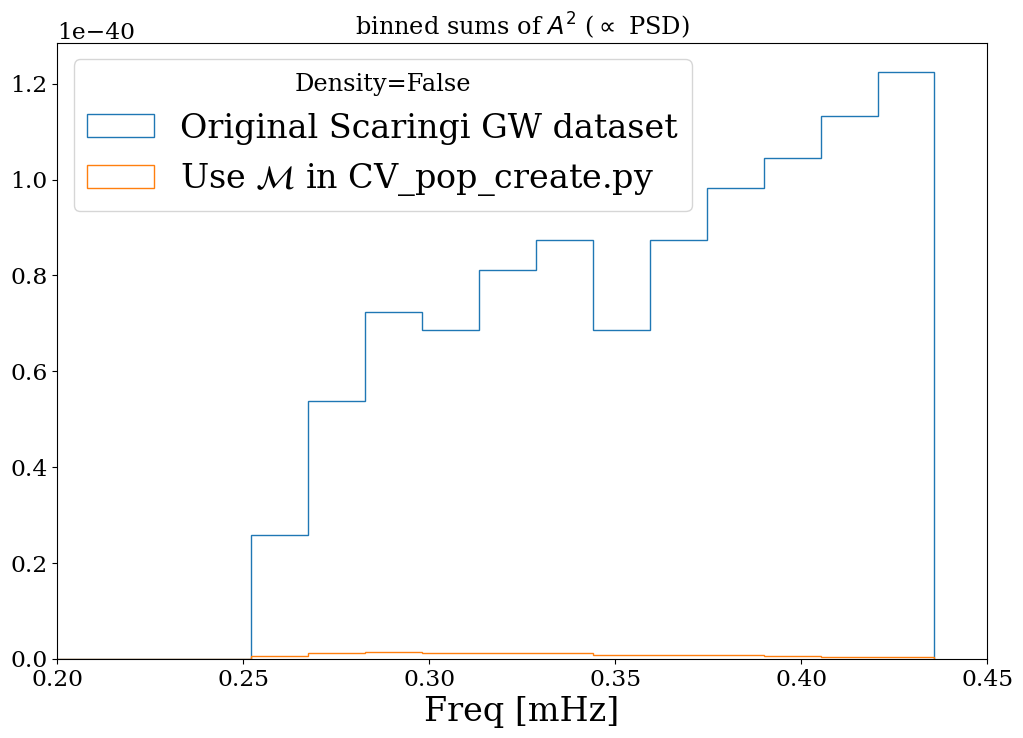

In [47]:
plt.hist(binaries['f[Hz]']*1e3, weights=binaries['Amp']**2, bins=25, histtype='step', density=False, label='Original Scaringi GW dataset')
#plt.hist(blip_df['f']*1e3, weights=blip_df['h']**2, bins=25, histtype='step', density=False, label='legwork h from CV population')
plt.hist(binaries_mc['f[Hz]']*1e3, weights=binaries_mc['Amp']**2, bins=25, histtype='step', density=False, label=r'Use $\mathcal{M}$ in CV_pop_create.py')
plt.xlabel('Freq [mHz]')
plt.title(r'binned sums of $A^2$ ($\propto$ PSD)', fontsize='xx-large')
plt.xlim(.2, 0.45)
plt.legend(title='Density=False', title_fontsize='xx-large')

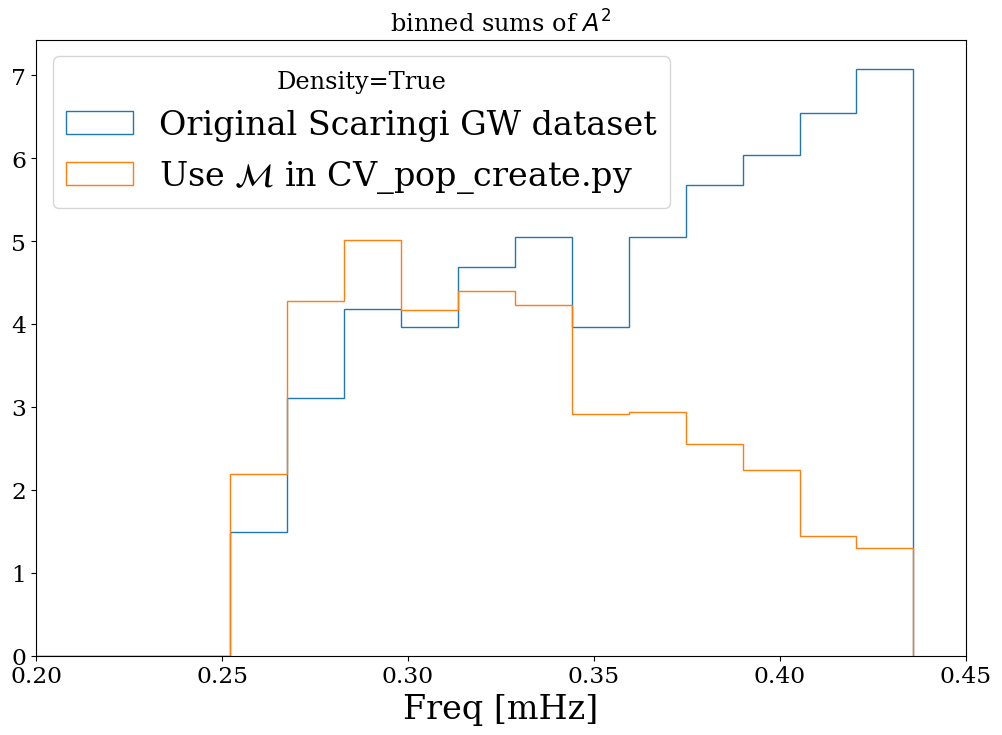

In [45]:
plt.hist(binaries['f[Hz]']*1e3, weights=binaries['Amp']**2, bins=25, histtype='step', density=True, label='Original Scaringi GW dataset')
#plt.hist(blip_df['f']*1e3, weights=blip_df['h']**2, bins=25, histtype='step', density=False, label='legwork h from CV population')
plt.hist(binaries_mc['f[Hz]']*1e3, weights=binaries_mc['Amp']**2, bins=25, histtype='step', density=True, label=r'Use $\mathcal{M}$ in CV_pop_create.py')
plt.xlabel('Freq [mHz]')
plt.title(r'binned sums of $A^2$', fontsize='xx-large')
plt.xlim(.2, 0.45)
plt.legend(title='Density=True', title_fontsize='xx-large')

- lets see the difference in strains

In [37]:
mc = lw.utils.chirp_mass(CV_pop['# m1[Msun]'],CV_pop[' m2[Msun]']).to_numpy()*u.Msun

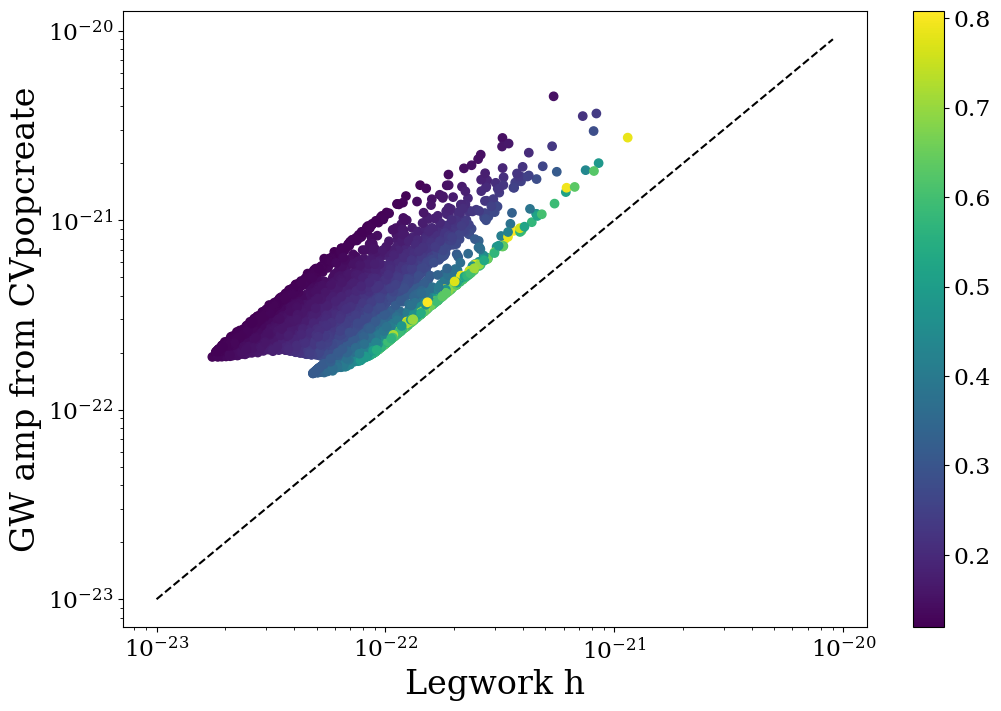

In [46]:
ar = np.arange(1e-23, 1e-20, 1e-21)
plt.scatter(blip_df['h'], binaries['Amp'], c=mc.value)
plt.xlabel('Legwork h')
plt.ylabel('GW amp from CVpopcreate')
plt.plot(ar, ar, ls='dashed', c='k')
plt.colorbar()
plt.loglog();

[]

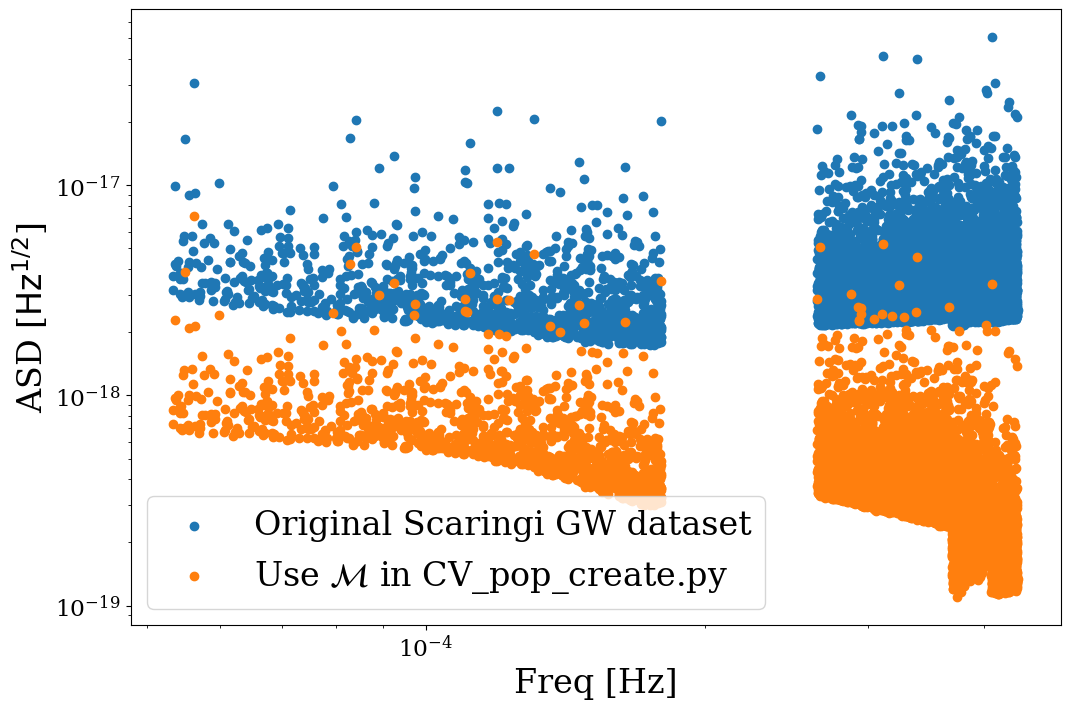

In [35]:
plt.scatter(binaries['f[Hz]'], binaries['Amp']*np.sqrt(4*3.15e7), label='Original Scaringi GW dataset')
plt.scatter(binaries_mc['f[Hz]'], binaries_mc['Amp']*np.sqrt(4*3.15e7), label=r'Use $\mathcal{M}$ in CV_pop_create.py')
plt.xlabel('Freq [Hz]')
plt.ylabel(r'ASD [$\rm{Hz}^{1/2}$]')
plt.legend(loc='lower left')
plt.loglog()

- importing remade data with chirp mass now

(0.2, 0.45)

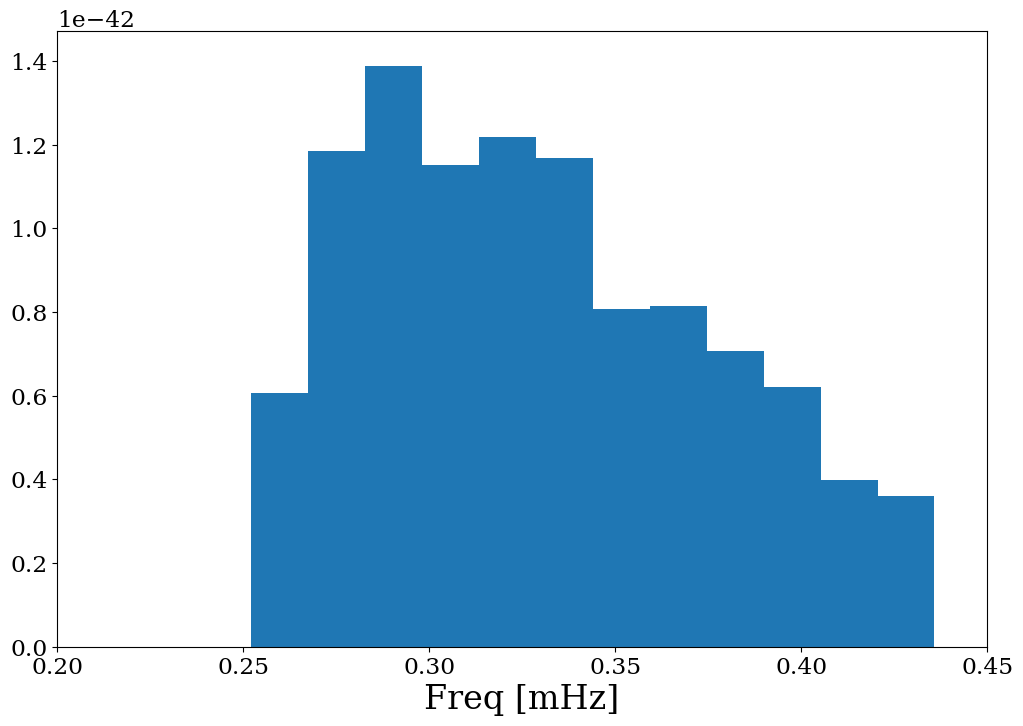

In [65]:
plt.hist(binaries_mc['f[Hz]']*1e3, weights=binaries_mc['Amp']**2, bins=25)
plt.xlabel('Freq [mHz]')
plt.xlim(.2, 0.45)

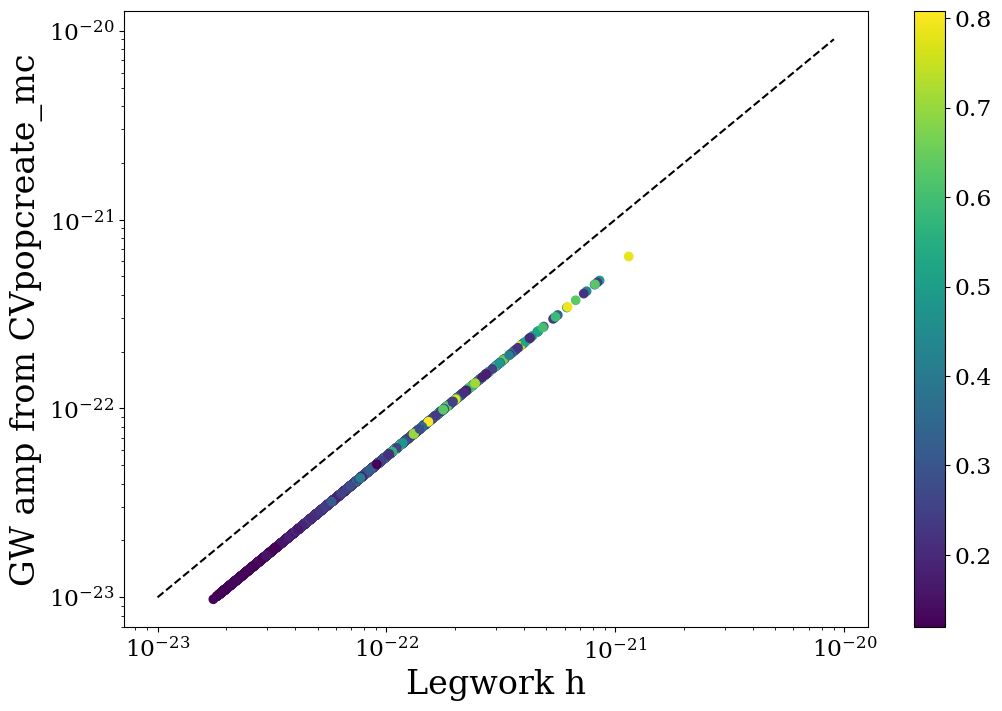

In [47]:
plt.scatter(blip_df['h'], binaries_mc['Amp'], c=mc.value)
plt.xlabel('Legwork h')
plt.ylabel('GW amp from CVpopcreate_mc')
plt.plot(ar, ar, ls='dashed', c='k')
# plt.xlim(1e-24, 2e-21)
# plt.ylim(1e-24, 2e-21)
plt.colorbar()
plt.loglog();

[]

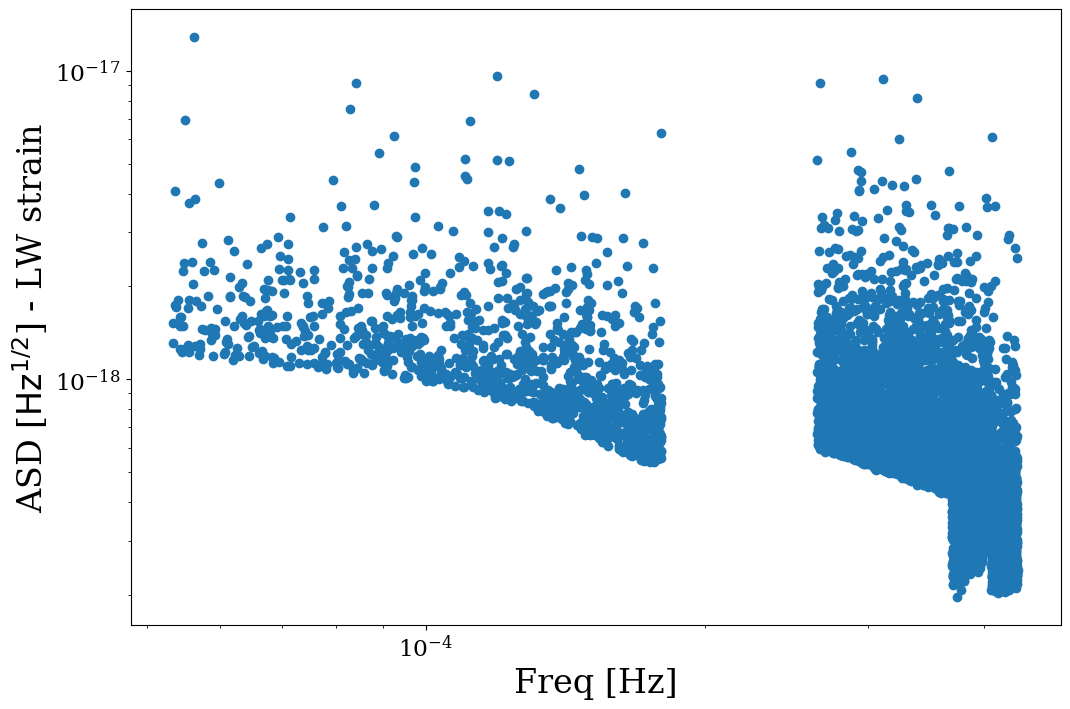

In [56]:
plt.scatter(blip_df['f'],blip_df['h']*np.sqrt(4*3.15e7))
plt.xlabel('Freq [Hz]')
plt.ylabel(r'ASD [$\rm{Hz}^{1/2}$] - LW strain')
plt.loglog()

[]

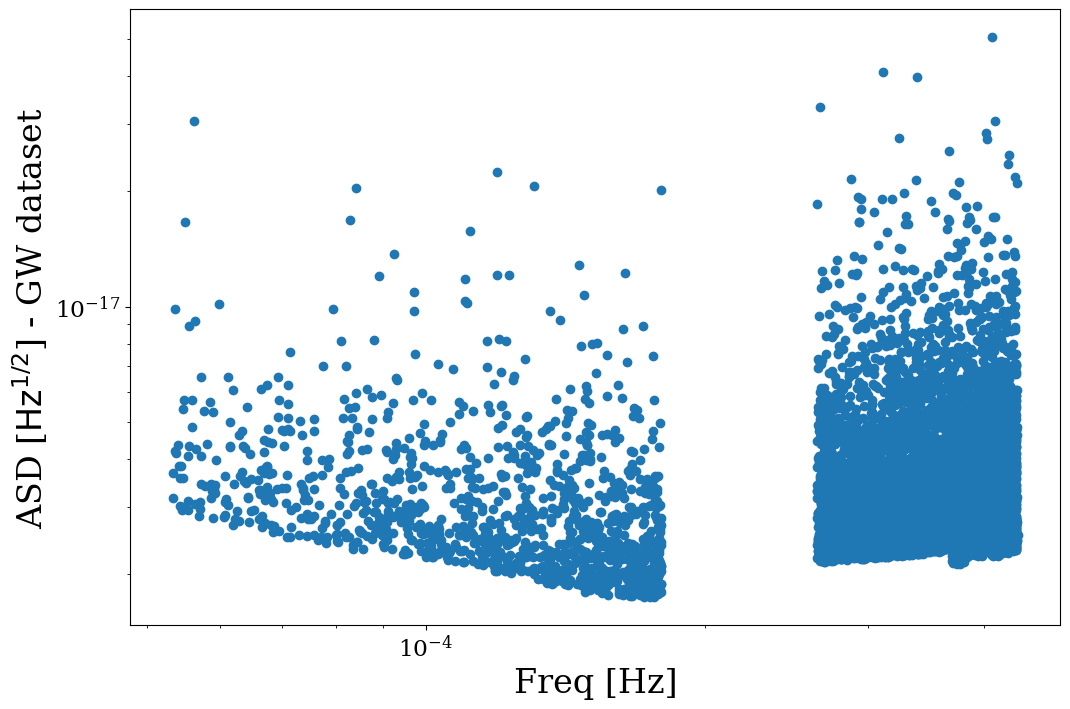

In [54]:
plt.scatter(binaries['f[Hz]'],binaries['Amp']*np.sqrt(4*3.15e7))
plt.xlabel('Freq [Hz]')
plt.ylabel(r'ASD [$\rm{Hz}^{1/2}$] - GW dataset')
plt.loglog()

[]

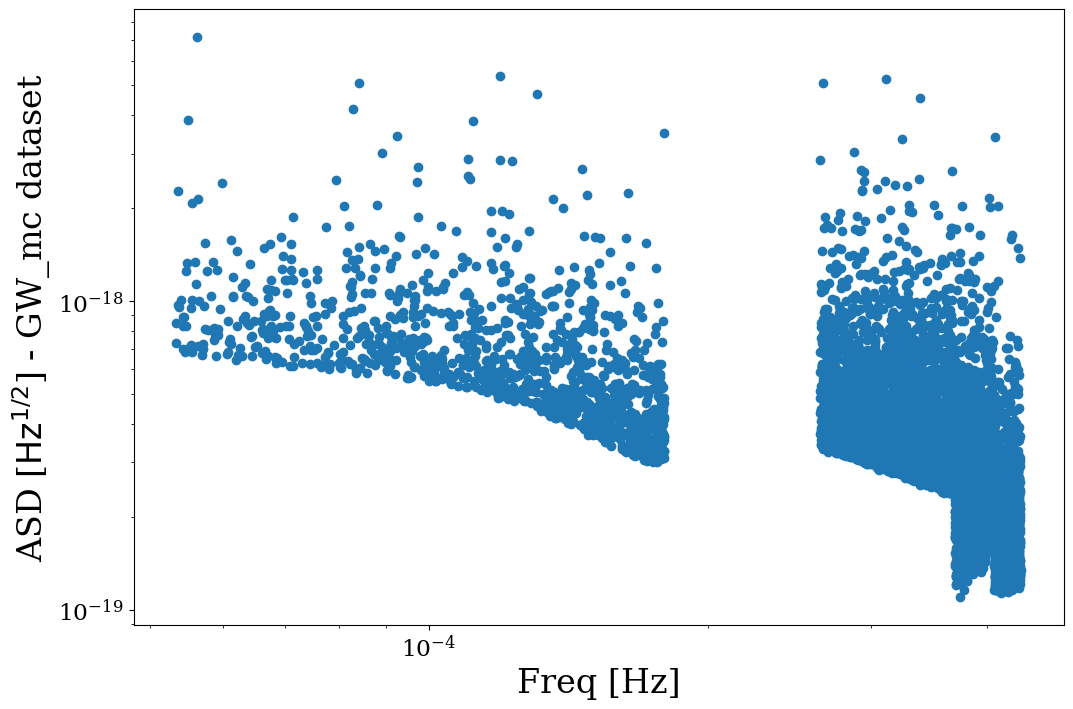

In [55]:
plt.scatter(binaries_mc['f[Hz]'],binaries_mc['Amp']*np.sqrt(4*3.15e7))
plt.xlabel('Freq [Hz]')
plt.ylabel(r'ASD [$\rm{Hz}^{1/2}$] - GW_mc dataset')
plt.loglog()